This notebook discusses the two Bayesian based ML method:
- **Naive Bayes** is a classifier. It's used to predict a category (e.g., "spam" or "not spam").

- **Bayesian Regression** is a regression model. It's used to predict a continuous value (e.g., $150,000 or $2.75).

Although both use Bayes' Theorem as a starting point, they are applied to different problems.

# Import

In [154]:
import os
import sys
sys.path.insert(0, "../..")
from sklearn import datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2, multivariate_normal
from mlfromscratch.utils import train_test_split, normalize, accuracy_score, Plot
from mlfromscratch.supervised_learning import NaiveBayes, BayesianRegression
from mlfromscratch.utils.data_manipulation import train_test_split, polynomial_features
from mlfromscratch.utils.data_operation import mean_squared_error
import math

# enable automatic reloading of Python modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Naive Bayes

Naive Bayes is a classifier that naively assumes that all the $X$ variables (the features) are conditionally independent of each other, given the class.

## Load Dataset

In [155]:
data = datasets.load_digits()
data.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [156]:
print("Predictor: ", data.data.shape)
print(data.frame)
print(data.feature_names[:5])
print(data.data[:5, :5])

print("Target: ", data.target.shape)
print(data.target_names)
print(data.target[:5])

Predictor:  (1797, 64)
None
['pixel_0_0', 'pixel_0_1', 'pixel_0_2', 'pixel_0_3', 'pixel_0_4']
[[ 0.  0.  5. 13.  9.]
 [ 0.  0.  0. 12. 13.]
 [ 0.  0.  0.  4. 15.]
 [ 0.  0.  7. 15. 13.]
 [ 0.  0.  0.  1. 11.]]
Target:  (1797,)
[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4]


Note the above target is a fixed class 0-9, and the predictor is a 8x8 dimension 2d pixels

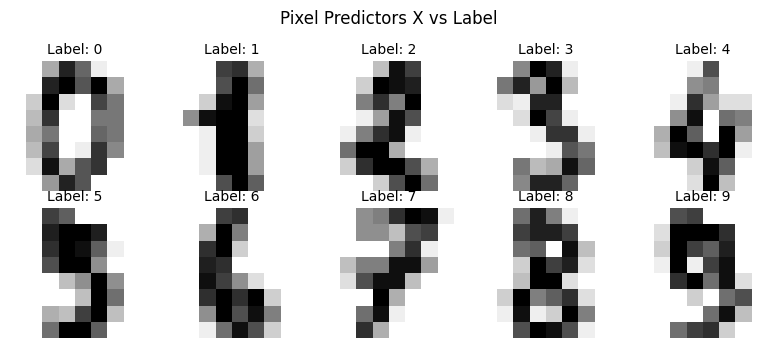

In [157]:
# visualize first 10 digit images
fig, axes = plt.subplots(2, 5, figsize=(8, 3.5))
axes = axes.flatten()

for i in range(10):
    # reshape 64-dim vector back to 8x8 image
    img = data.data[i].reshape(8, 8)
    sns.heatmap(img, ax=axes[i], cmap='gray_r', cbar=False, square=True, 
                xticklabels=False, yticklabels=False, linewidths=0)
    axes[i].set_title(f'Label: {data.target[i]}', fontsize=10, pad=5)
fig.suptitle("Pixel Predictors X vs Label")
plt.tight_layout()
plt.show()

## Preprocess

In [158]:
X = normalize(data.data)
y = data.target

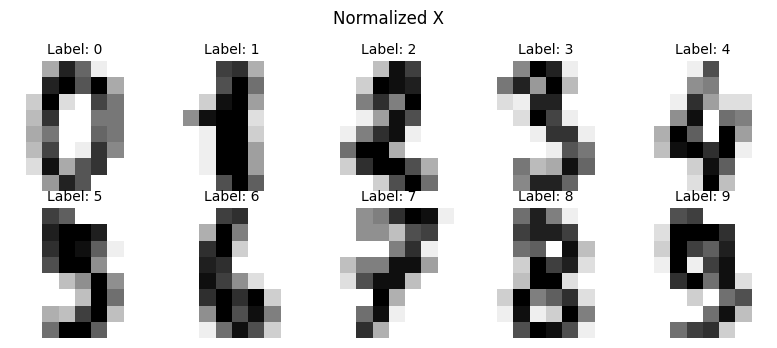

In [159]:
# recheck the above with normalized data
fig, axes = plt.subplots(2, 5, figsize=(8, 3.5))
axes = axes.flatten()

for i in range(10):
    # reshape 64-dim vector back to 8x8 image
    img = X[i].reshape(8, 8)
    sns.heatmap(img, ax=axes[i], cmap='gray_r', cbar=False, square=True, 
                xticklabels=False, yticklabels=False, linewidths=0)
    axes[i].set_title(f'Label: {y[i]}', fontsize=10, pad=5)
fig.suptitle("Normalized X")
plt.tight_layout()
plt.show()

In [160]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4)

## Decompose Classifier
- See modularized class in `supervised_learning/naive_bayes.py`

### Step 1: Identify unique classes in `y_train`

In [161]:
classes = np.unique(y_train)
print(f"Classes: {classes}")
print(f"Number of classes: {len(classes)}")

Classes: [0 1 2 3 4 5 6 7 8 9]
Number of classes: 10


### Step 2: Fit (For Likelihood calculation)
- Calculate mean and variance for each feature per class
- this is basically the "fit" weight of the naive bayes

In [162]:
# store parameters (mean, variance) for each class and feature
parameters = []

# get feature where class == 0, for example
c = 0
X_where_c = X_train[np.where(y_train == c)]
print(f"Class {c}: {X_where_c.shape[0]} samples")
print(f"Features shape: {X_where_c.shape}")

# calculate mean and variance for each of the 64 features
class_params = []
for col in X_where_c.T:  # iterate over features (columns)
    params = {"mean": col.mean(), "var": col.var()}
    class_params.append(params)

print(f"\nFirst 3 features for class {c}:")
for i in range(3):
    print(f"  Feature {i}: mean={class_params[i]['mean']:.4f}, var={class_params[i]['var']:.6f}")

Class 0: 99 samples
Features shape: (99, 64)

First 3 features for class 0:
  Feature 0: mean=0.0000, var=0.000000
  Feature 1: mean=0.0004, var=0.000015
  Feature 2: mean=0.0744, var=0.002498


In [163]:
# now do this for all classes
parameters = []
for i, c in enumerate(classes):
    X_where_c = X_train[np.where(y_train == c)]
    parameters.append([])
    # add the mean and variance for each feature
    for col in X_where_c.T:
        params = {"mean": col.mean(), "var": col.var()}
        parameters[i].append(params)

print(f"Stored parameters for {len(parameters)} classes")
print(f"Each class has {len(parameters[0])} feature parameters")
print(f"\nClass 5, Feature 30: {parameters[5][30]}")

Stored parameters for 10 classes
Each class has 64 feature parameters

Class 5, Feature 30: {'mean': np.float64(0.0075790926146355716), 'var': np.float64(0.0004894432760888764)}


### Step 3: Calculate Prior P(Y)
Prior is the probability of each class occurring in the training data (in this case we use the mean)
- can think about this as a "baseline" random guess model

In [164]:
# calculate prior for each class
def calculate_prior(y, c):
    """calculate the prior of class c"""
    frequency = np.mean(y == c)
    return frequency

# check priors for all classes
print("Priors:")
for c in np.sort(classes):
    prior = calculate_prior(y_train, c)
    print(f"  P(Y={c}) = {prior:.4f}")

Priors:
  P(Y=0) = 0.0918
  P(Y=1) = 0.1047
  P(Y=2) = 0.1001
  P(Y=3) = 0.1029
  P(Y=4) = 0.0908
  P(Y=5) = 0.1010
  P(Y=6) = 0.1029
  P(Y=7) = 0.1001
  P(Y=8) = 0.1001
  P(Y=9) = 0.1057


### Step 4: Calculate Likelihood P(X|Y)
Likelihood is the probability of feature values given a class (using Gaussian distribution)
- notice this mean and var is calculated from all features where each result is equal to the given class

In [165]:
def calculate_likelihood(mean, var, x):
    """gaussian likelihood of the data x given mean and var"""
    eps = 1e-4  # prevent division by zero
    # decomponse the gauissan PDF into coeff and exp
    coeff = 1.0 / math.sqrt(2.0 * math.pi * var + eps)
    exponent = math.exp(-(math.pow(x - mean, 2) / (2 * var + eps)))
    return coeff * exponent

# example: calculate likelihood for a single feature value
exp_class = 5
exp_feature = 30
mean_example = parameters[exp_class][exp_feature]['mean']  # class 0, feature 0
var_example = parameters[exp_class][exp_feature]['var']
x_example = X_test[exp_class][exp_feature]  # first test sample, first feature

likelihood = calculate_likelihood(mean_example, var_example, x_example)
print(f"Example likelihood of Class: {exp_class}, Feature: {exp_feature}:")
print(f"  Feature value: {x_example:.4f}")
print(f"  Mean: {mean_example:.4f}, Var: {var_example:.6f}")
print(f"  Likelihood: {likelihood:.6f}")

Example likelihood of Class: 5, Feature: 30:
  Feature value: 0.1256
  Mean: 0.0076, Var: 0.000489
  Likelihood: 0.000044


Here we don't need actual probabilities, just relative likelihoods to compare which class is most probable so raw PDF value is working

### Step 5: Classify using Bayes Rule
**P(Y|X) = P(X|Y) × P(Y) / P(X)**

- **Posterior P(Y|X)**: probability that sample belongs to class Y given features X
- **Likelihood P(X|Y)**: probability of features X given class Y (Gaussian)  
- **Prior P(Y)**: probability of class Y
- **P(X)**: scaling factor (ignored since it's constant across all classes)

Sample classification:
  True label: 5
  Predicted label: 5

Posteriors for each class:


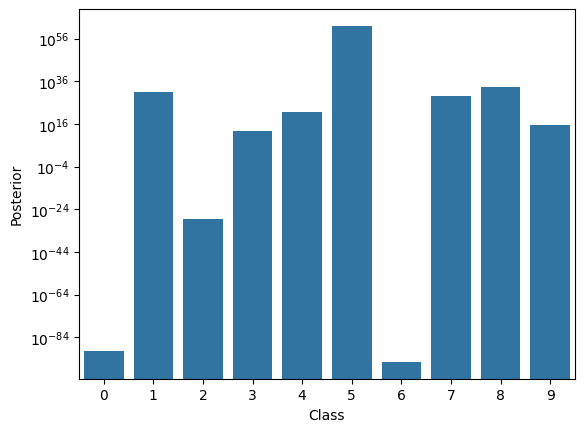

In [166]:
def classify(sample, classes, parameters, y_train):
    """classify a single sample using Bayes rule"""
    posteriors = []
    
    # go through each class
    for i, c in enumerate(classes):
        # initialize posterior as prior
        posterior = calculate_prior(y_train, c)
        
        # naive assumption: features are independent
        # P(x1,x2,...,x64|Y) = P(x1|Y) × P(x2|Y) × ... × P(x64|Y)
        for feature_value, params in zip(sample, parameters[i]):
            likelihood = calculate_likelihood(params["mean"], params["var"], feature_value)
            # update posterior
            posterior *= likelihood
        
        posteriors.append(posterior)
    
    # return the class with largest posterior
    return classes[np.argmax(posteriors)], posteriors

# classify first test sample
sample = X_test[0]
predicted_class, posteriors = classify(sample, classes, parameters, y_train)

print(f"Sample classification:")
print(f"  True label: {y_test[0]}")
print(f"  Predicted label: {predicted_class}")
print(f"\nPosteriors for each class:")
posteriors_plot = []
for i, c in enumerate(classes):
    posteriors_plot.append({"Class": c, "Posterior": posteriors[i]})
posteriors_plot = pd.DataFrame(posteriors_plot)
g = sns.barplot(posteriors_plot, x="Class", y="Posterior")
g.set_yscale("log")

### Step 6: Predict all test samples

In [167]:
# predict all test samples
y_pred = []
for sample in X_test:
    pred_class, _ = classify(sample, classes, parameters, y_train)
    y_pred.append(int(pred_class))

# calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Manual implementation accuracy: {accuracy:.4f}")

# compare first 20 predictions
print(f"\nFirst 20 predictions:")
print(f"True:      {y_test[:20]}")
print(f"Predicted: {y_pred[:20]}")

Manual implementation accuracy: 0.9136

First 20 predictions:
True:      [5 1 0 7 9 0 4 9 7 4 9 1 2 6 2 7 6 0 0 2]
Predicted: [5, 1, 0, 7, 7, 0, 4, 9, 7, 7, 3, 1, 2, 6, 2, 5, 6, 0, 4, 2]


## Zero Probability Issue

Issue where the class never exists from training data which will make the training likelihood zero

Use **Laplace Smoothing**: adding a small "pseudo-count" ($\alpha$, usually 1) to every count. This ensures that no probability can ever be exactly zero. By adding 1 (our $\alpha$) to every word's count, even a word that has never been seen before will have a small, non-zero probability, allowing the calculation to proceed

# Bayesian Regression

## Load Dataset

In [210]:
try:
    # when running as a script
    absdir = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # when running in a Jupyter notebook (no __file__)
    absdir = os.getcwd()
data_filepath = os.path.join(absdir, "../..", "mlfromscratch/data/TempLinkoping2016.txt")
data = pd.read_csv(data_filepath, sep="\t")

time = np.atleast_2d(data["time"].values).T
temp = np.atleast_2d(data["temp"].values).T

X = time # fraction of the year [0, 1]
y = temp

# manually amplify uncertain
thresh = np.where(X < 0.4)
y[thresh] = y[thresh] * (np.random.default_rng(42).uniform(-1, 1, len(y[thresh])) * 2)

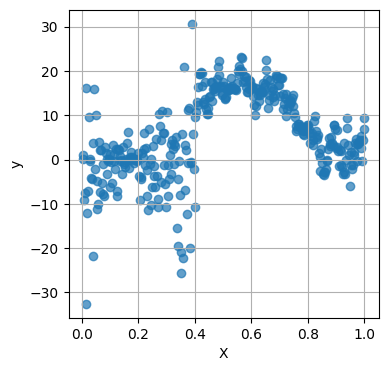

In [211]:
plt.figure(figsize=(4, 4))
plt.scatter(X.ravel(), y, alpha=0.7)
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.show()

## Preprocess

In [239]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

n_samples, n_features = np.shape(X)

## Decompose Regressor

### Step 1: Init Params

In [213]:
# init weights
poly_degree = 4
cred_int = 10 # 10% credit interval

### Step 2: Init Prior

- Assume a normal likelihood prior
- Assume unknown variance as scaled inverse chi-square prior
- mu0 is the prior on regression coefficients (β).  
    - Zero-centered priors on coeff are standard practice, expressing no prior preference for positive or negative relationships
- Also use very weak priors: omega0 = np.diag([.0001] * n_features) (low precision = high variance) and sigma_sq0 = 100
    - which means the prior has minimal influence

In [214]:
# init prior
mu0 = np.array([0] * n_features)
omega0 = np.diag([0.0001] * n_features)
# Scaled inverse chi-squared
nu0 = 1
sigma_sq0 = 100

### Step 3: Calulate Posterior
With prior assumptions above, the posterior from the conjugate prior is also scaled inverse chi-squared - which is a closed form that does not need MCMC sampling

See [Bayesian Linear Regression](https://en.wikipedia.org/wiki/Bayesian_linear_regression)

In [215]:
# init weights
w = None

# polynomial transformation
if poly_degree:
    X_train_poly = polynomial_features(X_train, degree=poly_degree)
else:
    X_train_poly = X_train.copy()

n_samples, n_features = np.shape(X_train_poly)
X_X_train = X_train_poly.T.dot(X_train_poly)
print(X.shape, X_X_train.shape)
# shape = degree + constant
print(X_X_train)

(366, 1) (5, 5)
[[257.         129.14754098  87.20709785  66.00169312  53.10574074]
 [129.14754098  87.20709785  66.00169312  53.10574074  44.43221581]
 [ 87.20709785  66.00169312  53.10574074  44.43221581  38.21239314]
 [ 66.00169312  53.10574074  44.43221581  38.21239314  33.54548875]
 [ 53.10574074  44.43221581  38.21239314  33.54548875  29.92163204]]


In [216]:
# Least squares approximate of beta using Moore–Penrose pseudoinverse
beta_hat = np.linalg.pinv(X_X_train).dot(X_train_poly.T).dot(y_train)
print(beta_hat.shape)
print(beta_hat)

(5, 1)
[[    5.6283309 ]
 [ -173.43580505]
 [  896.12349884]
 [-1318.69727307]
 [  592.15747412]]


- The above computes the ordinary least squares (OLS) estimate of the regression coefficients: β̂ = (X'X)⁻¹X'y [Moore–Penrose pseudoinverse](https://en.wikipedia.org/wiki/Moore%E2%80%93Penrose_inverse)
- β̂ represents the maximum likelihood estimate of the coefficients
- For the below conjugate calculation see: [Conjugate Prior](https://en.wikipedia.org/wiki/Conjugate_prior)

In [217]:
# The posterior parameters can be determined analytically since we assume
# conjugate priors for the likelihoods.

# Normal prior / likelihood => Normal posterior
mu_n = np.linalg.pinv(X_X_train + omega0).dot(X_X_train.dot(beta_hat)+omega0.dot(mu0))
omega_n = X_X_train + omega0

# Scaled inverse chi-squared prior / likelihood => Scaled inverse chi-squared posterior
nu_n = nu0 + n_samples
sigma_sq_n = (1.0/nu_n)*(nu0*sigma_sq0 + \
    (y_train.T.dot(y_train) + mu0.T.dot(omega0).dot(mu0) - mu_n.T.dot(omega_n.dot(mu_n))))


In [218]:
print("=== Priors: ===")
print("normal likelihood prior: ", mu0, omega0)
print("inverse chi2 conjugate prior: ", nu0, sigma_sq0)
print("=== Posteriors: ===")
print("normal mean posterior", mu_n, omega_n)
print("inverse chi2 variance posterior: ", nu_n, sigma_sq_n)

=== Priors: ===
normal likelihood prior:  [0] [[0.0001]]
inverse chi2 conjugate prior:  1 100
=== Posteriors: ===
normal mean posterior [[    5.62832785]
 [ -173.4357312 ]
 [  896.12310828]
 [-1318.69657822]
 [  592.1570837 ]] [[257.0001     129.14764098  87.20719785  66.00179312  53.10584074]
 [129.14764098  87.20719785  66.00179312  53.10584074  44.43231581]
 [ 87.20719785  66.00179312  53.10584074  44.43231581  38.21249314]
 [ 66.00179312  53.10584074  44.43231581  38.21249314  33.54558875]
 [ 53.10584074  44.43231581  38.21249314  33.54558875  29.92173204]]
inverse chi2 variance posterior:  258 [[31.19702082]]


In [219]:
# Simulate parameter values for n_draws
n_draws = 2000
beta_draws = np.empty((n_draws, n_features))


def _draw_scaled_inv_chi_sq(n, df, scale):
    X = chi2.rvs(size=n, df=df)
    sigma_sq = df * scale / X
    return sigma_sq

for i in range(n_draws):
    # simulate to get a beta posterior distribution 
    sigma_sq = _draw_scaled_inv_chi_sq(n=1, df=nu_n, scale=sigma_sq_n)
    beta = multivariate_normal.rvs(
        size=1, mean=mu_n[:, 0], cov=sigma_sq * np.linalg.pinv(omega_n)
    )
    # Save parameter draws
    beta_draws[i, :] = beta


- The residuals (y - Xβ̂) measure how well the OLS fit explains the data
- The sum of squared residuals (y - X.dot(beta_hat)).T.dot(y - X.dot(beta_hat)) goes into updating the scaled inverse chi-squared posterior for σ² 

<Axes: ylabel='Count'>

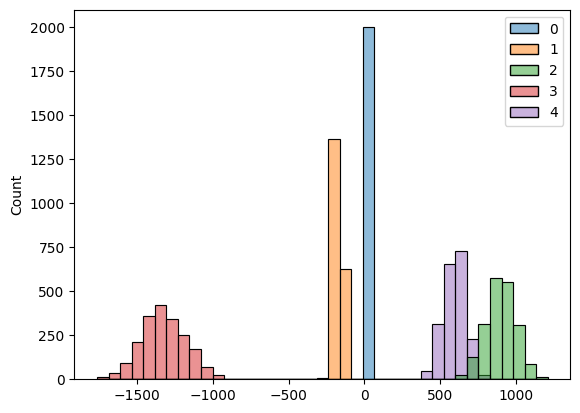

In [220]:
sns.histplot(beta_draws)

### Step 4: Update Weights and Form CI

In [221]:
# update weight
w = np.mean(beta_draws, axis=0)
# Lower and upper boundary of the credible interval
l_eti = 50 - cred_int / 2 
u_eti = 50 + cred_int / 2
# if 5% ci then take from 47.5% to 52.5% mean ci
eti = np.array(
    [
        [
            np.percentile(beta_draws[:, i], q=l_eti),
            np.percentile(beta_draws[:, i], q=u_eti),
        ]
        for i in range(n_features)
    ]
)


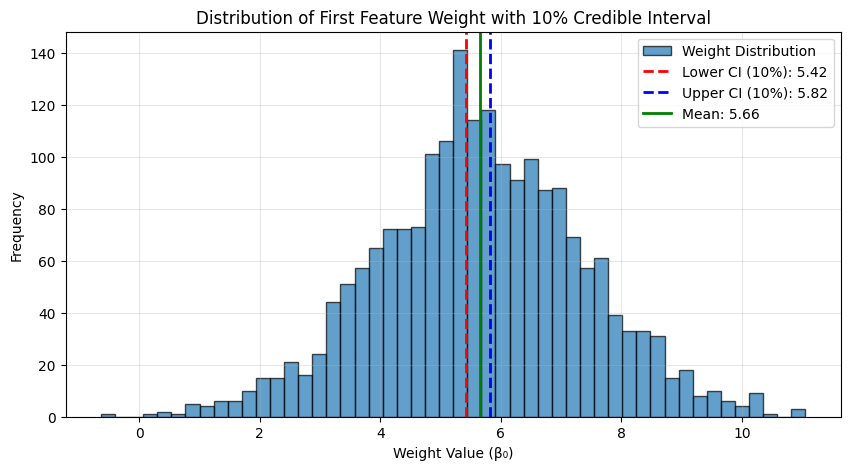

In [222]:
# histogram plot for first feature (w[:, 0]) with credible interval
plt.figure(figsize=(10, 5))

# plot histogram of first feature weights
plt.hist(beta_draws[:, 0], bins=50, alpha=0.7, edgecolor='black', label='Weight Distribution')

# add vertical lines for credible interval
lower_bound = eti[0, 0]
upper_bound = eti[0, 1]
plt.axvline(x=lower_bound, color='red', linestyle='--', linewidth=2, label=f'Lower CI ({cred_int}%): {lower_bound:.2f}')
plt.axvline(x=upper_bound, color='blue', linestyle='--', linewidth=2, label=f'Upper CI ({cred_int}%): {upper_bound:.2f}')

# add mean line
mean_weight = w[0]
plt.axvline(x=mean_weight, color='green', linestyle='-', linewidth=2, label=f'Mean: {mean_weight:.2f}')

plt.xlabel('Weight Value (β₀)')
plt.ylabel('Frequency')
plt.title(f'Distribution of First Feature Weight with {cred_int}% Credible Interval')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [223]:
print("Coeff:", w)
print("Coeff Lower", eti[:, 0])
print("Coeff Upper", eti[:, 1])

Coeff: [    5.65692542  -174.15017361   899.54647468 -1324.05383918
   594.83318847]
Coeff Lower [    5.41855202  -177.21734577   890.19221259 -1348.5885318
   588.83355002]
Coeff Upper [    5.8243913   -171.16775087   913.26230209 -1311.74008672
   608.03401196]


### Step 5: Predict

In [224]:
# If polynomial transformation
if poly_degree:
    X_test_poly = polynomial_features(X_test, degree=poly_degree)

# use the trained w
y_pred = X_test_poly.dot(w)
# If the lower and upper boundaries for the 95%
# equal tail interval should be returned

lower_w = eti[:, 0]
upper_w = eti[:, 1]
y_lower_pred = X_test_poly.dot(lower_w)
y_upper_pred = X_test_poly.dot(upper_w)

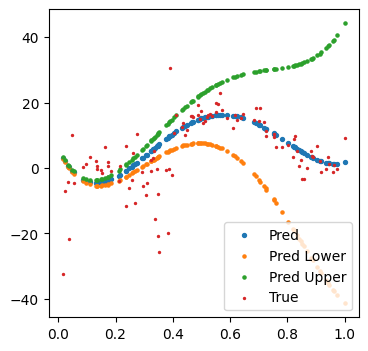

In [225]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(x=X_test, y=y_pred, label="Pred", s=8)
ax.scatter(x=X_test, y=y_lower_pred, label="Pred Lower", s=5)
ax.scatter(x=X_test, y=y_upper_pred, label="Pred Upper", s=5)
ax.scatter(x=X_test, y=y_test, label="True", s=2)
ax.legend(loc="lower right")

## Run Class As A Whole

In [235]:
def train_and_plot(
    poly_degree, mu0, omega0, nu0, sigma_sq0, cred_int, X_train, y_train, X_test, y_test
):
    clf = BayesianRegression(
        n_draws=2000,
        poly_degree=poly_degree,
        mu0=mu0,
        omega0=omega0,
        nu0=nu0,
        sigma_sq0=sigma_sq0,
        cred_int=cred_int,
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    mse_test = mean_squared_error(y_test, y_pred)

    # Get prediction line
    y_pred_, y_lower_, y_upper_ = clf.predict(X=X, eti=True)

    # Print the mean squared error
    print("Mean Squared Error:", mse_test)

    # Color map
    cmap = plt.get_cmap("viridis")

    # Plot the results
    m1 = plt.scatter(366 * X_train, y_train, color=cmap(0.9), s=10)
    m2 = plt.scatter(366 * X_test, y_test, color=cmap(0.5), s=10)
    p1 = plt.plot(366 * X, y_pred_, color="black", linewidth=2, label="Prediction")
    p2 = plt.plot(
        366 * X,
        y_lower_,
        color="gray",
        linewidth=2,
        label="{0}% Credible Interval".format(cred_int),
    )
    p3 = plt.plot(366 * X, y_upper_, color="gray", linewidth=2)
    plt.axis((0, 366, -20, 25))
    plt.suptitle("Bayesian Regression")
    plt.title("Test MSE: %.2f" % mse_test, fontsize=10)
    plt.xlabel("Day")
    plt.ylabel("Temperature in Celcius")
    plt.legend(loc="lower right")
    # plt.legend((m1, m2), ("Training data", "Test data"), loc='lower right')
    plt.legend(loc="lower right")

    plt.show()

Mean Squared Error: 128.50152513650514


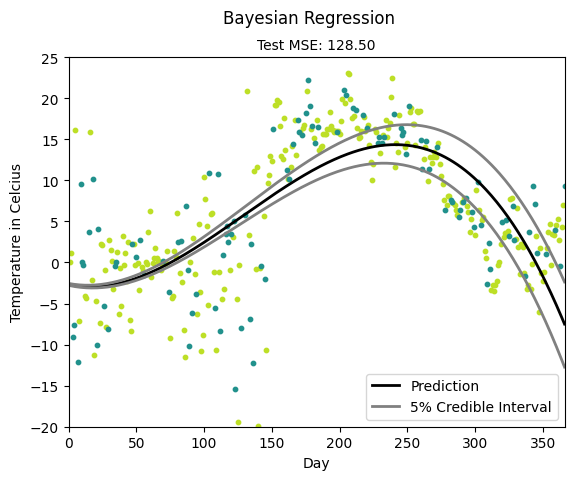

In [246]:
# Prior parameters
# - Weights are assumed distr. according to a Normal distribution
# - The variance of the weights are assumed distributed according to
#   a scaled inverse chi-squared distribution.
# High prior uncertainty!
# Normal
mu0 = np.array([0] * n_features)
omega0 = np.diag([0.0001] * n_features)
# Scaled inverse chi-squared
nu0 = 1
sigma_sq0 = 100

# assign credible interval
cred_int = 5

ploy_degree = 3
train_and_plot(
    ploy_degree, mu0, omega0, nu0, sigma_sq0, cred_int, X_train, y_train, X_test, y_test
)


- Why CI widens over time: With polynomial features (degree=4), predictions are: $$y = w_0 + w_1 x + w_2 x^2 + w_3 x^3 + w_4 x^4$$
- Early in year: x ≈ 0, so higher-order terms are small → uncertainty mainly from w_0, w_1
- Later in year: x ≈ 1, so x^3, x^4 terms become significant → uncertainty accumulates across all polynomial terms
- Each coefficient has uncertainty (credible interval)
Higher powers amplify the uncertainty: small variance in w_4 becomes large when multiplied by x^4
- This is characteristic of polynomial regression - **predictions become less certain** as you move away from the data-dense regions, and **polynomial terms amplify uncertainty** at the extremes!